<a href="https://colab.research.google.com/github/bndto-s0clsta/Spline_cUbico_fiee/blob/main/Spline_Cubico2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from scipy.interpolate import CubicSpline

# ==========================
# Datos del examen
# ==========================

f = np.array([
10.0,12.5,15.0,17.5,20.0,22.5,25.0,27.5,30.0,32.5,
35.0,37.5,40.0,42.5,45.0,47.5,50.0,52.5,55.0,57.5,
60.0,62.5,65.0,67.5,70.0,72.5,75.0,77.5,80.0,82.5,
85.0,87.5,90.0,92.5,95.0,97.5,100.0,102.5,105.0,107.5
])

V = np.array([
0.842,0.911,0.986,1.062,1.143,1.227,1.314,1.401,1.482,1.551,
1.216,1.048,0.866,0.689,0.521,0.364,0.223,0.103,0.012,-0.041,
-0.057,-0.034,0.018,0.096,0.197,0.318,0.452,0.579,0.700,0.809,
0.611,0.688,0.756,0.811,0.856,0.894,0.926,0.954,0.980,1.004
])

Z = np.array([
182.4,178.9,175.1,171.0,166.8,162.7,158.9,155.4,152.0,149.0,
146.1,145.2,145.8,147.3,149.9,153.5,158.0,163.2,168.9,174.8,
180.5,186.2,191.5,196.2,200.1,203.1,205.2,206.3,206.1,204.7,
198.0,194.4,190.9,187.8,185.1,183.0,181.6,180.8,180.6,180.9
])

# ==========================
# Función Lagrange grado 2
# ==========================

def lagrange2(x, xp, yp):

    n = len(xp)
    P = 0

    for i in range(n):

        Li = 1

        for j in range(n):
            if i != j:
                Li *= (x - xp[j])/(xp[i]-xp[j])

        P += yp[i]*Li

    return P

# ==========================
# Interpolación en 41 kHz
# ==========================

f41 = np.array([37.5,40.0,42.5])

V41_pts = np.array([1.048,0.866,0.689])
Z41_pts = np.array([145.2,145.8,147.3])

V_41_lag = lagrange2(41.0, f41, V41_pts)
Z_41_lag = lagrange2(41.0, f41, Z41_pts)

# ==========================
# Interpolación en 73 kHz
# ==========================

f73 = np.array([70.0,72.5,75.0])

V73_pts = np.array([0.197,0.318,0.452])
Z73_pts = np.array([200.1,203.1,205.2])

V_73_lag = lagrange2(73.0, f73, V73_pts)
Z_73_lag = lagrange2(73.0, f73, Z73_pts)

# ==========================
# Spline cúbico natural
# ==========================

spline_V = CubicSpline(f, V, bc_type='natural')
spline_Z = CubicSpline(f, Z, bc_type='natural')

V_41_spline = spline_V(41.0)
Z_41_spline = spline_Z(41.0)

V_73_spline = spline_V(73.0)
Z_73_spline = spline_Z(73.0)

# ==========================
# Resultados
# ==========================

print("="*50)
print("LAGRANGE GRADO 2")
print("="*50)

print(f"V(41)  = {V_41_lag:.6f} V")
print(f"|Z|(41)= {Z_41_lag:.6f} Ohm")

print()

print(f"V(73)  = {V_73_lag:.6f} V")
print(f"|Z|(73)= {Z_73_lag:.6f} Ohm")

print("\n")

print("="*50)
print("SPLINE CÚBICO NATURAL")
print("="*50)

print(f"V(41)  = {V_41_spline:.6f} V")
print(f"|Z|(41)= {Z_41_spline:.6f} Ohm")

print()

print(f"V(73)  = {V_73_spline:.6f} V")
print(f"|Z|(73)= {Z_73_spline:.6f} Ohm")

LAGRANGE GRADO 2
V(41)  = 0.794600 V
|Z|(41)= 146.292000 Ohm

V(73)  = 0.343760 V
|Z|(73)= 203.592000 Ohm


SPLINE CÚBICO NATURAL
V(41)  = 0.792320 V
|Z|(41)= 146.285958 Ohm

V(73)  = 0.344157 V
|Z|(73)= 203.588820 Ohm


DERIVADA PROGRESIVA ORDEN 2
dV/df(10 kHz) = 0.026400 V/kHz


DERIVADAS DEL SPLINE
dV/df(10 kHz)  = 0.026953
dV/df(40 kHz)  = -0.076862
dV/df(70 kHz)  = 0.044657
dV/df(100 kHz) = 0.011805


COMPARACIÓN DE MÉTODOS
   Frecuencia (kHz)  Orden 2   Orden 4                Spline  \
0                40  -0.0718 -0.072567  -0.07686195121982699   
1                70   0.0444  0.044733  0.044657300354569975   
2               100   0.0120  0.011867  0.011805196263699311   

   Error % O2 vs Spline  Error % O4 vs Spline  
0              6.585770              5.588311  
1              0.576166              0.170259  
2              1.650152              0.520706  


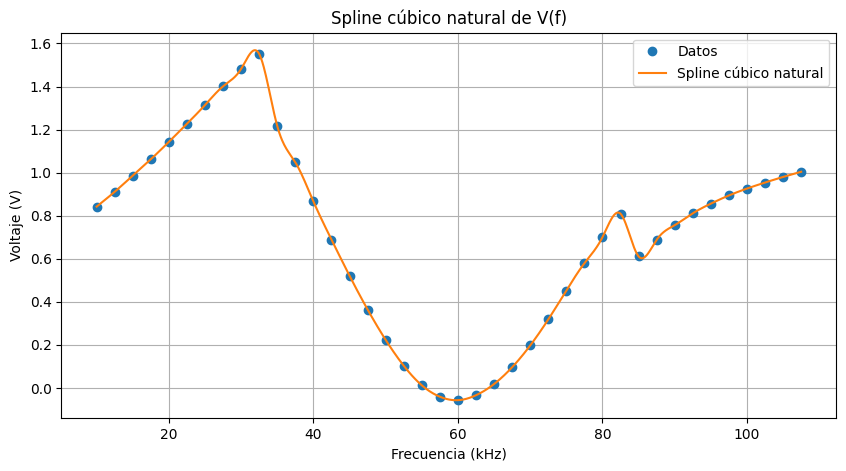

In [2]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline

# ====================================================
# DATOS DEL EXAMEN
# ====================================================

f = np.array([
10.0,12.5,15.0,17.5,20.0,22.5,25.0,27.5,30.0,32.5,
35.0,37.5,40.0,42.5,45.0,47.5,50.0,52.5,55.0,57.5,
60.0,62.5,65.0,67.5,70.0,72.5,75.0,77.5,80.0,82.5,
85.0,87.5,90.0,92.5,95.0,97.5,100.0,102.5,105.0,107.5
])

V = np.array([
0.842,0.911,0.986,1.062,1.143,1.227,1.314,1.401,1.482,1.551,
1.216,1.048,0.866,0.689,0.521,0.364,0.223,0.103,0.012,-0.041,
-0.057,-0.034,0.018,0.096,0.197,0.318,0.452,0.579,0.700,0.809,
0.611,0.688,0.756,0.811,0.856,0.894,0.926,0.954,0.980,1.004
])

# ====================================================
# PASO ENTRE MUESTRAS
# ====================================================

h = 2.5

# ====================================================
# DIFERENCIAS FINITAS
# ====================================================

def diferencia_centrada_orden2(y_m1, y_p1):
    return (y_p1 - y_m1)/(2*h)

def diferencia_centrada_orden4(y_m2, y_m1, y_p1, y_p2):
    return (-y_p2 + 8*y_p1 - 8*y_m1 + y_m2)/(12*h)

def diferencia_progresiva_orden2(y0, y1, y2):
    return (-3*y0 + 4*y1 - y2)/(2*h)

# ====================================================
# f = 40 kHz
# ====================================================

d2_40 = diferencia_centrada_orden2(
    1.048,
    0.689
)

d4_40 = diferencia_centrada_orden4(
    1.216,
    1.048,
    0.689,
    0.521
)

# ====================================================
# f = 70 kHz
# ====================================================

d2_70 = diferencia_centrada_orden2(
    0.096,
    0.318
)

d4_70 = diferencia_centrada_orden4(
    0.018,
    0.096,
    0.318,
    0.452
)

# ====================================================
# f = 100 kHz
# ====================================================

d2_100 = diferencia_centrada_orden2(
    0.894,
    0.954
)

d4_100 = diferencia_centrada_orden4(
    0.856,
    0.894,
    0.954,
    0.980
)

# ====================================================
# EXTREMO INFERIOR f = 10 kHz
# ====================================================

dprog_10 = diferencia_progresiva_orden2(
    0.842,
    0.911,
    0.986
)

# ====================================================
# SPLINE CÚBICO NATURAL
# ====================================================

spline_V = CubicSpline(
    f,
    V,
    bc_type='natural'
)

# Derivada del spline

dV_spline = spline_V.derivative()

# ====================================================
# EVALUACIÓN DE DERIVADAS DEL SPLINE
# ====================================================

ds_40 = dV_spline(40)
ds_70 = dV_spline(70)
ds_100 = dV_spline(100)
ds_10 = dV_spline(10)

# ====================================================
# ERROR PORCENTUAL
# ====================================================

def error_porcentual(valor, referencia):

    if abs(referencia) < 1e-12:
        return np.nan

    return abs((valor - referencia)/referencia)*100

# ====================================================
# TABLA COMPARATIVA
# ====================================================

tabla = pd.DataFrame({

    "Frecuencia (kHz)":[40,70,100],

    "Orden 2":[
        d2_40,
        d2_70,
        d2_100
    ],

    "Orden 4":[
        d4_40,
        d4_70,
        d4_100
    ],

    "Spline":[
        ds_40,
        ds_70,
        ds_100
    ],

    "Error % O2 vs Spline":[
        error_porcentual(d2_40,ds_40),
        error_porcentual(d2_70,ds_70),
        error_porcentual(d2_100,ds_100)
    ],

    "Error % O4 vs Spline":[
        error_porcentual(d4_40,ds_40),
        error_porcentual(d4_70,ds_70),
        error_porcentual(d4_100,ds_100)
    ]
})

# ====================================================
# RESULTADOS
# ====================================================

print("="*60)
print("DERIVADA PROGRESIVA ORDEN 2")
print("="*60)

print(f"dV/df(10 kHz) = {dprog_10:.6f} V/kHz")

print("\n")

print("="*60)
print("DERIVADAS DEL SPLINE")
print("="*60)

print(f"dV/df(10 kHz)  = {ds_10:.6f}")
print(f"dV/df(40 kHz)  = {ds_40:.6f}")
print(f"dV/df(70 kHz)  = {ds_70:.6f}")
print(f"dV/df(100 kHz) = {ds_100:.6f}")

print("\n")

print("="*60)
print("COMPARACIÓN DE MÉTODOS")
print("="*60)

print(tabla.round(6))

# ====================================================
# GRÁFICA OPCIONAL
# ====================================================

import matplotlib.pyplot as plt

f_fino = np.linspace(min(f), max(f), 1000)

plt.figure(figsize=(10,5))
plt.plot(f, V, 'o', label='Datos')
plt.plot(f_fino, spline_V(f_fino),
         label='Spline cúbico natural')

plt.xlabel('Frecuencia (kHz)')
plt.ylabel('Voltaje (V)')
plt.title('Spline cúbico natural de V(f)')
plt.grid(True)
plt.legend()
plt.show()

In [3]:
from scipy.interpolate import CubicSpline

# =====================================
# Construcción del spline cúbico natural
# =====================================

spline_V = CubicSpline(
    f,
    V,
    bc_type='natural'
)

# =====================================
# Método de bisección
# =====================================

a = 55.0
b = 57.5

tol = 1e-6
iteracion = 0

print("Iter\t a\t\t b\t\t c\t\t S(c)")

while (b - a)/2 > tol:

    c = (a + b)/2

    print(
        f"{iteracion}\t"
        f"{a:.6f}\t"
        f"{b:.6f}\t"
        f"{c:.6f}\t"
        f"{spline_V(c):.8f}"
    )

    if spline_V(a)*spline_V(c) < 0:
        b = c
    else:
        a = c

    iteracion += 1

raiz = (a + b)/2

print("\n======================")
print("Primera raíz encontrada")
print("======================")
print(f"f = {raiz:.8f} kHz")
print(f"V(f) = {spline_V(raiz):.10f}")

Iter	 a		 b		 c		 S(c)
0	55.000000	57.500000	56.250000	-0.01923197
1	55.000000	56.250000	55.625000	-0.00485485
2	55.000000	55.625000	55.312500	0.00325587
3	55.312500	55.625000	55.468750	-0.00087779
4	55.312500	55.468750	55.390625	0.00116936
5	55.390625	55.468750	55.429688	0.00014088
6	55.429688	55.468750	55.449219	-0.00036968
7	55.429688	55.449219	55.439453	-0.00011471
8	55.429688	55.439453	55.434570	0.00001301
9	55.434570	55.439453	55.437012	-0.00005087
10	55.434570	55.437012	55.435791	-0.00001894
11	55.434570	55.435791	55.435181	-0.00000297
12	55.434570	55.435181	55.434875	0.00000502
13	55.434875	55.435181	55.435028	0.00000103
14	55.435028	55.435181	55.435104	-0.00000097
15	55.435028	55.435104	55.435066	0.00000003
16	55.435066	55.435104	55.435085	-0.00000047
17	55.435066	55.435085	55.435076	-0.00000022
18	55.435066	55.435076	55.435071	-0.00000010
19	55.435066	55.435071	55.435069	-0.00000003
20	55.435066	55.435069	55.435067	-0.00000000

Primera raíz encontrada
f = 55.43506682 kHz
V(f)